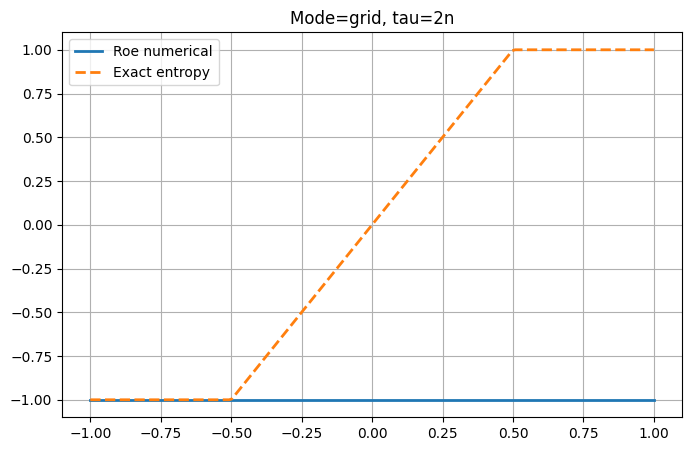

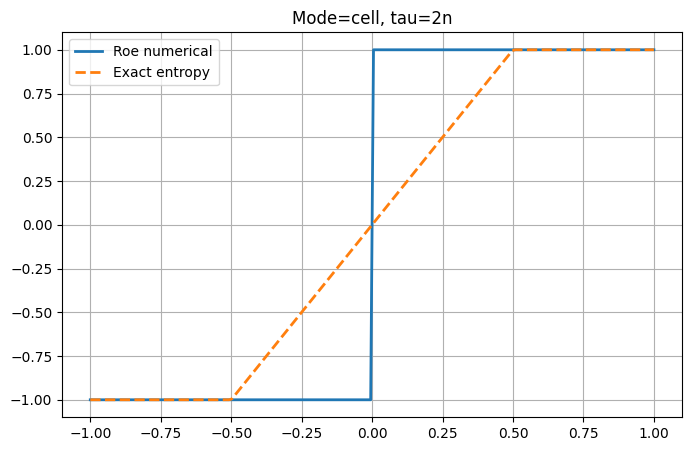

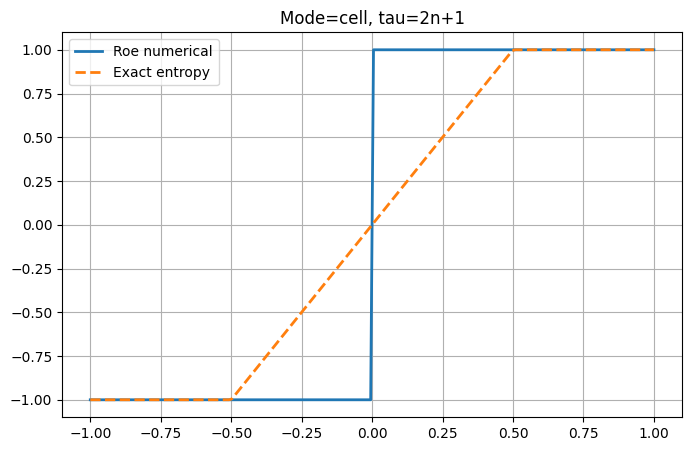

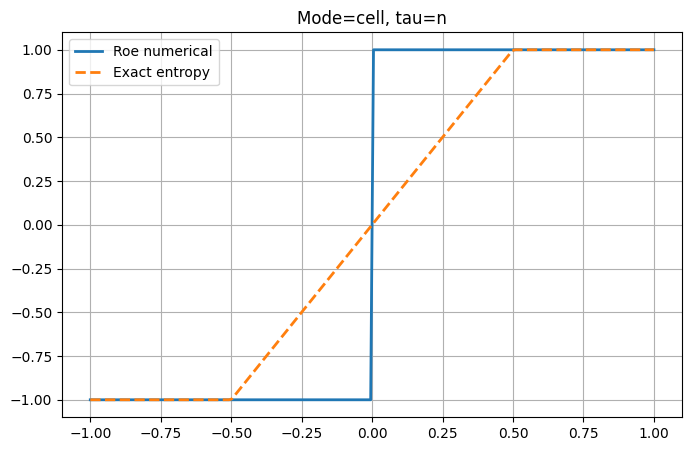

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def flux(u):
    return 0.5 * u**2

def roe_flux(u, v):
    c = (0.5 * (u + v))
    if c>=0:
        return u**2 /2
    else:
        return v**2 /2



def exact_solution(x, t):
    u = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi < -t:
            u[i] = -1
        elif xi > t:
            u[i] = 1
        else:
            u[i] = xi / t
    return u


def initial_grid_point(x):
    return np.where(x <= 1, -1.0, 1.0)

def initial_cell_average(x, dx):
    u = np.zeros_like(x)
    for i in range(len(x)):
        xl = x[i] - dx/2
        xr = x[i] + dx/2
        if xr <= 0:
            u[i] = -1
        elif xl >= 0:
            u[i] = 1
        else:
            u[i] = ( (0 - xl)*(-1) + (xr - 0)*(1) ) / (xr - xl)
    return u

def roe_solver(u0, dx, dt, T):
    u = u0.copy()
    N = len(u)
    t = 0.0

    while t < T:
        u_new = u.copy()
        for j in range(1, N-1):
            f_plus = roe_flux(u[j], u[j+1])
            f_minus = roe_flux(u[j-1], u[j])
            u_new[j] = u[j] - (dt/dx) * (f_plus - f_minus)
        u = u_new
        t += dt

    return u

def run_experiment(N=200, T=0.5, CFL=0.5, mode="grid", tau_type="2n"):
    x = np.linspace(-1, 1, N)
    dx = x[1] - x[0]

    if tau_type == "2n":
        dt = dx / (2 * int(1/dx))
    elif tau_type == "2n+1":
        dt = dx / (2 * int(1/dx) + 1)
    elif tau_type == "n":
        dt = dx / int(1/dx)
    else:
        dt = CFL * dx

    if mode == "grid":
        u0 = initial_grid_point(x)
    else:
        u0 = initial_cell_average(x, dx)

    u_num = roe_solver(u0, dx, dt, T)
    u_exact = exact_solution(x, T)

    plt.figure(figsize=(8,5))
    plt.plot(x, u_num, label="Roe numerical", linewidth=2)
    plt.plot(x, u_exact, '--', label="Exact entropy", linewidth=2)
    plt.title(f"Mode={mode}, tau={tau_type}")
    plt.legend()
    plt.grid()
    plt.show()


run_experiment(mode="grid")

run_experiment(mode="cell", tau_type="2n")

run_experiment(mode="cell", tau_type="2n+1")

run_experiment(mode="cell", tau_type="n")

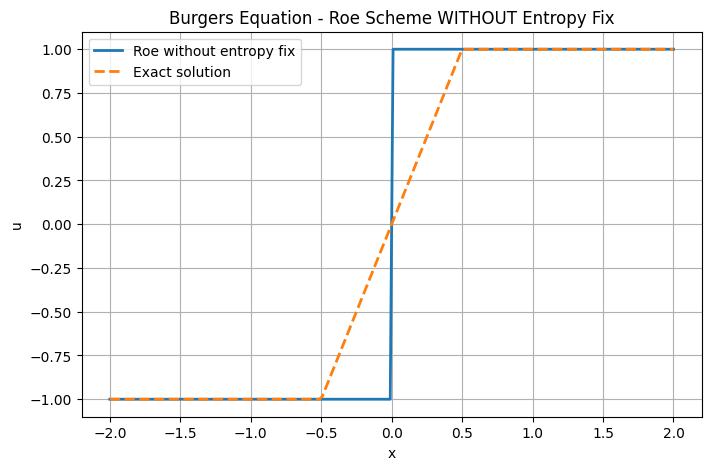

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def roe_flux(uL, uR):

    # Roe speed
    c = 0.5 * (uL + uR)

    # Upwind according to Roe speed
    if c > 0:
        return 0.5 * uL**2
    else:
        return 0.5 * uR**2


# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
Nx = 200
x_min = -2.0
x_max = 2.0

x = np.linspace(x_min, x_max, Nx)

dx = x[1] - x[0]


# ------------------------------------------------------------
# Initial condition
#
# u = -1   for x <= 0
# u =  1   for x > 0
# ------------------------------------------------------------
u = np.where(x <= 0, -1.0, 1.0)


# ------------------------------------------------------------
# Time parameters
# ------------------------------------------------------------
CFL = 0.8
t = 0.0
t_final = 0.5


# ------------------------------------------------------------
# Time integration loop
# ------------------------------------------------------------
while t < t_final:

    # maximum wave speed
    max_speed = np.max(np.abs(u))

    dt = CFL * dx / max_speed

    # avoid overshooting final time
    if t + dt > t_final:
        dt = t_final - t

    # fluxes at interfaces
    F = np.zeros(Nx + 1)

    # compute Roe fluxes
    for i in range(1, Nx):

        uL = u[i - 1]
        uR = u[i]

        F[i] = roe_flux(uL, uR)

    # update solution
    u_new = u.copy()

    for i in range(1, Nx - 1):

        u_new[i] = (
            u[i]
            - (dt / dx) * (F[i + 1] - F[i])
        )

    u = u_new
    t += dt


# ------------------------------------------------------------
# Exact rarefaction solution
# ------------------------------------------------------------
u_exact = np.zeros_like(x)

for i in range(Nx):

    xi = x[i] / t_final

    if xi < -1:
        u_exact[i] = -1

    elif xi > 1:
        u_exact[i] = 1

    else:
        u_exact[i] = xi


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(x, u, label="Roe without entropy fix", linewidth=2)

plt.plot(
    x,
    u_exact,
    '--',
    label="Exact solution",
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("u")
plt.title("Burgers Equation - Roe Scheme")

plt.legend()
plt.grid(True)

plt.show()

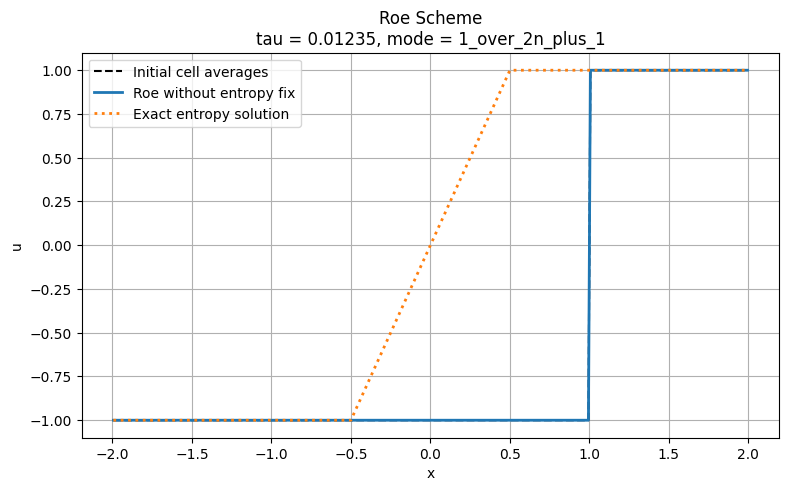

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Burgers equation using Roe scheme WITHOUT entropy fix
#
# Part (b): initial condition using CELL AVERAGES
#
# You can test:
#     tau = 1/(2*n)
#     tau = 1/(2*n+1)
#     tau = 1/n
# by changing the function below.
# ============================================================


# ------------------------------------------------------------
# Roe flux (WITHOUT entropy fix)
# ------------------------------------------------------------
def roe_flux(uL, uR):

    c = 0.5 * (uL + uR)

    if c > 0:
        return 0.5 * uL**2
    else:
        return 0.5 * uR**2


# ------------------------------------------------------------
# Choose sequence tau_n
# ------------------------------------------------------------
def tau_sequence(n, mode="1_over_2n"):

    if mode == "1_over_2n":
        return 1.0 / (2 * n)

    elif mode == "1_over_2n_plus_1":
        return 1.0 / (2 * n + 1)

    elif mode == "1_over_n":
        return 1.0 / n

    else:
        raise ValueError("Unknown mode")


# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
n = 40

#mode = "1_over_2n"
mode = "1_over_2n_plus_1"
#mode = "1_over_n"

tau = tau_sequence(n, mode)

CFL = 0.5

dx = tau
dt = CFL * dx

# domain
x_min = -2.0
x_max = 2.0

# cell centers
x = np.arange(x_min + dx/2, x_max, dx)

Nx = len(x)


# ------------------------------------------------------------
# INITIAL CONDITION USING CELL AVERAGES
# ------------------------------------------------------------
u = np.zeros(Nx)

for j in range(Nx):

    # cell boundaries
    xL = x[j] - dx/2
    xR = x[j] + dx/2

    # Entirely left of discontinuity
    if xR <= 1:
        u[j] = -1.0

    # Entirely right of discontinuity
    elif xL >= 1:
        u[j] = 1.0

    # Cell crosses x = 0
    else:

        # average over cell
        left_part = 1 - xL
        right_part = xR - 1

        integral = (-1)*left_part + (1)*right_part

        u[j] = integral / dx


# Save initial condition
u0 = u.copy()


# ------------------------------------------------------------
# FINAL TIME
# ------------------------------------------------------------
t_final = 0.5
t = 0.0


# ------------------------------------------------------------
# TIME LOOP
# ------------------------------------------------------------
while t < t_final:

    # adjust last timestep
    if t + dt > t_final:
        dt = t_final - t

    # fluxes
    F = np.zeros(Nx + 1)

    for j in range(1, Nx):

        F[j] = roe_flux(u[j-1], u[j])

    # update
    u_new = u.copy()

    for j in range(1, Nx-1):

        u_new[j] = (
            u[j]
            - (dt/dx)*(F[j+1] - F[j])
        )

    u = u_new
    t += dt


# ------------------------------------------------------------
# Exact entropy solution (rarefaction)
# ------------------------------------------------------------
u_exact = np.zeros_like(x)

for j in range(Nx):

    xi = x[j] / t_final

    if xi < -1:
        u_exact[j] = -1

    elif xi > 1:
        u_exact[j] = 1

    else:
        u_exact[j] = xi


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(9,5))

plt.plot(
    x,
    u0,
    'k--',
    label='Initial cell averages'
)

plt.plot(
    x,
    u,
    linewidth=2,
    label='Roe without entropy fix'
)

plt.plot(
    x,
    u_exact,
    linewidth=2,
    linestyle=':',
    label='Exact entropy solution'
)

plt.xlabel("x")
plt.ylabel("u")

plt.title(
    f"Roe Scheme\n"
    f"tau = {tau:.5f}, mode = {mode}"
)

plt.grid(True)
plt.legend()

plt.show()